# Korea: Pre-Announcement Positioning and the Earnings Baseline - Research Record

This is the working record of the positioning research. Every number and chart below is produced from the result files by the build script, not hand-entered. The question was whether Korea's daily investor-flow disclosure -- unusual among markets -- tells you anything about what happens after an earnings announcement, and if so, what.

| | |
| --- | --- |
| universe | provisional and periodic earnings filings, 2011-03-18 to 2026-06-01, 123,757 events |
| positioning measure | net institutional buying over the 20 trading days before the filing, scaled by turnover, standardised against the stock's own history |
| outcome | 60-trading-day return net of the equal-weight market, winsorised 1/99 within the day |
| estimator | one vote per event, regressors rank-standardised within the day, errors clustered on the reporting season |
| what the flow is | a record of the price move, not a forecast: quintile spread +985 bp going in (t +29.5), +37 bp coming out (t +0.75) |
| where the hypothesis holds | the tail, not the mean: after the strongest surprises, crowded names' 10th percentile is -236 bp worse (t -3.24), median and hit rate unchanged |
| foreign ownership flow | no forward information: +9.8 bp/SD, t +0.59 |


## Data used, and which fields

| store | fields used | how the field is used |
| --- | --- | --- |
| market (KRX, daily) | trade_date, ticker, close, value_traded, market_cap | daily returns, 60-day forward returns, benchmark, turnover, size, volatility controls |
| investor_flow (KRX, daily) | trade_date, ticker, investor, net_value | net buying by investor group; the 20-day institutional baseline and its foreign counterpart |
| foreign_ownership (KRX, daily) | trade_date, ticker, foreign_pct | ownership level and its 20-day change, tested as level-type measures |
| investor detail (per ticker, 2018 on) | seven institutional sub-categories, other corporations, retail | decomposition of the aggregate into its components |
| earnings filings (DART) | rcept_dt, ticker, report_nm, kind | event dates; provisional announcements separated from periodic reports |


# Part A - What the daily flow disclosure actually is

## Step 1 - The event-time path by pre-announcement flow

`data: market + investor_flow + earnings filings  (provisional announcements)`

**Question: does institutional buying before an announcement tell you what happens after it?**

Stocks are sorted each announcement day into quintiles of the 20-day institutional flow, and the benchmark-adjusted return is followed from 20 days before to 60 days after. The quintiles separate by +985 bp before the announcement (t +29.5) and by +37 bp after it (t +0.75). The flow records the move that has already happened. It does not forecast the one to come. This is the fact the rest of the record is organised around.

| flow quintile | events | run-up, day -20 to -1 (bp) | after, day +1 to +60 (bp) |
| --- | --- | --- | --- |
| 1 | 2,910 | -554 | -16 |
| 2 | 3,972 | -235 | -7 |
| 3 | 4,095 | +19 | +25 |
| 4 | 3,972 | +191 | -5 |
| 5 | 5,668 | +427 | +2 |


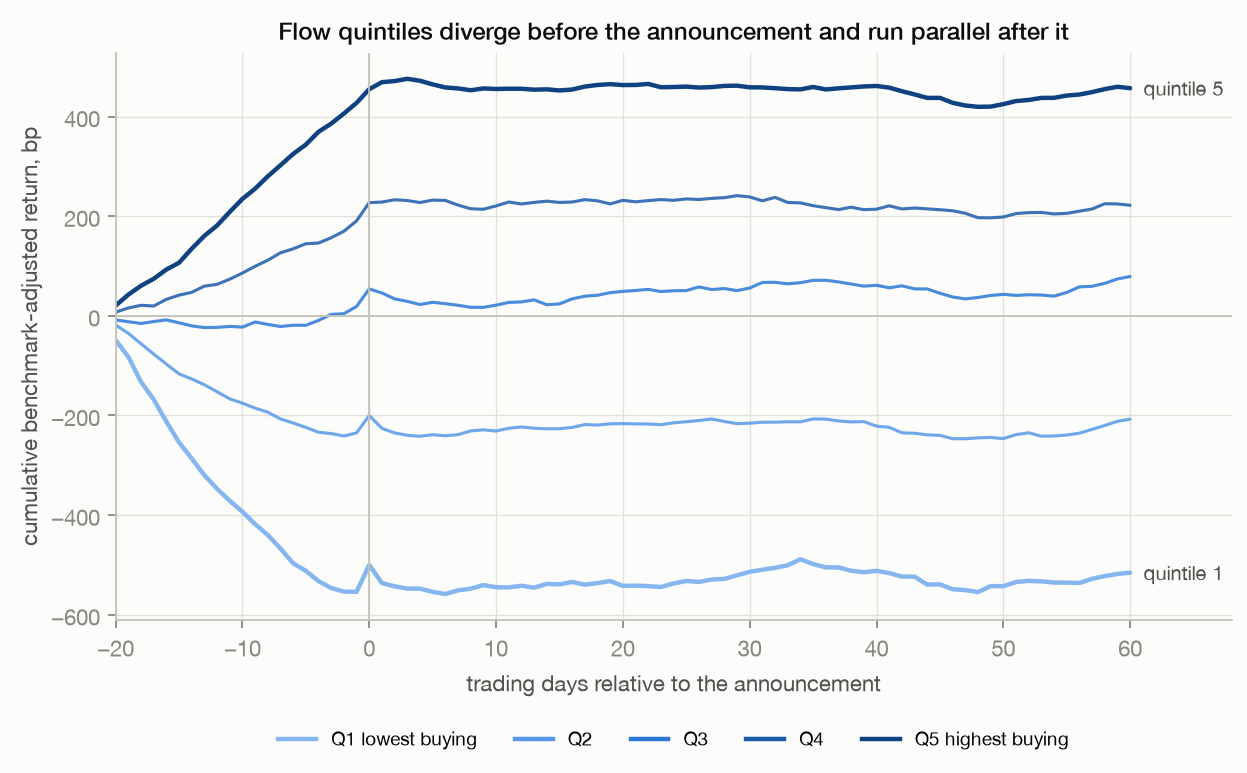

In [ ]:
# Step 1 - event-time path by flow quintile

## Step 2 - The original question: foreign flow, and the domestic series next to it

`data: market + investor_flow + earnings filings  (provisional, 2011-2026)`

**Question: does the daily foreign-ownership disclosure carry forward information around earnings?**

It does not. Foreign flow reads +9.8 bp per standard deviation at t +0.59 across 61 reporting seasons and 20,036 events, and the result did not move when the sample was doubled. The domestic institutional series carries a negative coefficient of -42.9 bp/SD (t -2.51) in the full specification. The next step shows what that coefficient is made of.

| series | coefficient (bp/SD) | t | events | seasons |
| --- | --- | --- | --- | --- |
| foreign flow | +9.8 | +0.59 | 20,036 | 61 |
| domestic institutional flow | -42.9 | -2.51 | 17,841 | 61 |


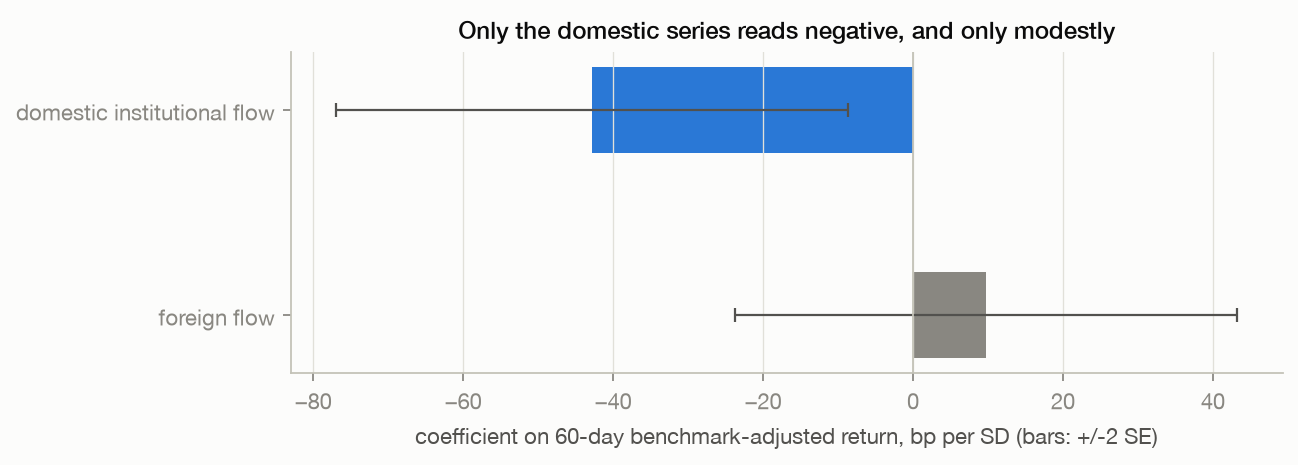

In [ ]:
# Step 2 - foreign vs institutional

## Step 3 - What the institutional coefficient is made of

`data: market + investor_flow + earnings filings  (provisional, 2011-2026)`

**Question: is the negative coefficient a property of the flow, or of the controls?**

Controls are added one group at a time. Without momentum the coefficient is -25.1 at t -1.67, short of significance; the momentum controls take it to -42.9 at t -2.51. Since the 20-day run-up is what the flow mostly measures, the coefficient is best read as "among stocks that ran up the same amount, the ones institutions bought more of do slightly worse" -- a residual after momentum, not a forecast. Read alongside Step 1, the mean of the return is not where positioning tells you anything.

| specification | coefficient (bp/SD) | t |
| --- | --- | --- |
| baseline alone | -25.1 | -1.67 |
| + surprise | -25.9 | -1.74 |
| + size, vol, turnover | -27.8 | -1.89 |
| + momentum (the full set) | -42.9 | -2.51 |


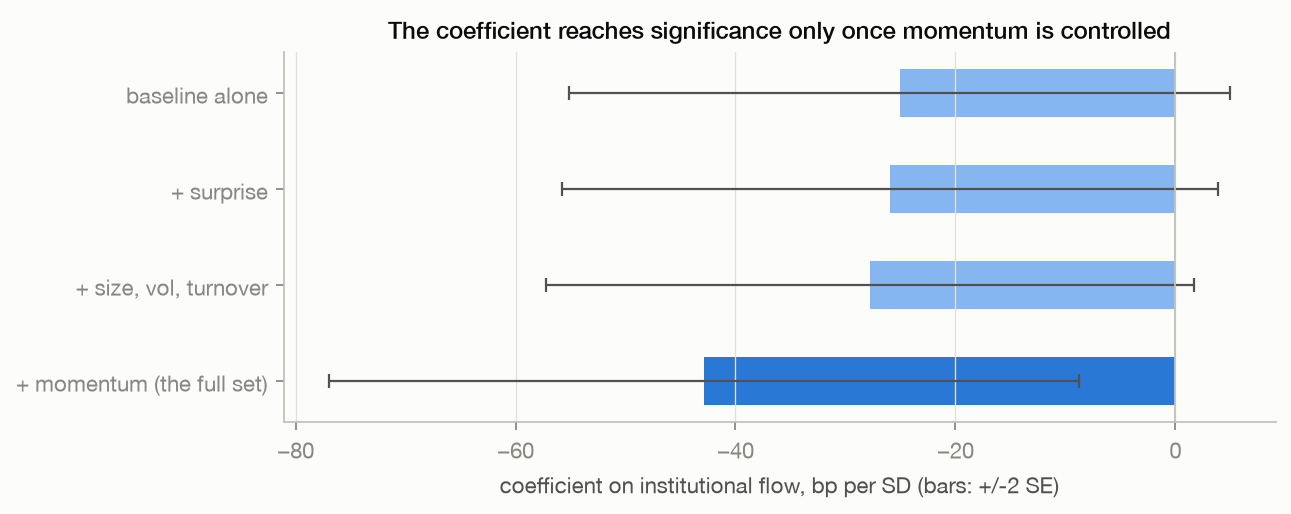

In [ ]:
# Step 3 - control ladder

# Part B - Where positioning does inform the baseline: the tail

## Step 4 - The baseline expectation, as a distribution

`data: market + investor_flow + earnings filings  (provisional, 20,617 events)`

**Question: what should be expected after a surprise of a given strength, and does prior positioning change that?**

A baseline expectation is a distribution, not a mean. Each announcement is placed by surprise quintile (the announcement-day reaction) and by crowding tercile (institutional buying over the prior 20 days), and the distribution of the following 60-day return is tabulated. The mean and the hit rate barely move with crowding. The tenth percentile does: among the strongest surprises it runs from -1,953.3 bp for uncrowded names to -2,176.6 bp for crowded ones. Crowding changes what a good print earns when it goes wrong, not what it earns on average. Full table for the two extreme surprise quintiles:

| surprise quintile | crowding | n | mean (bp) | median (bp) | p10 (bp) | hit rate | loss > 10% |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 5 | quiet | 1,263 | +146.4 | -197.7 | -1,953.3 | 45.5% | 27.6% |
| 5 | mid | 1,669 | +114.2 | -189.3 | -2,092.6 | 45.8% | 28.3% |
| 5 | crowded | 2,735 | +34.2 | -212.4 | -2,176.6 | 44.8% | 29.5% |
| 1 | quiet | 881 | -112.5 | -294.6 | -2,204.7 | 40.7% | 31.4% |
| 1 | mid | 940 | +51.0 | -357.3 | -2,100.2 | 41.4% | 32.6% |
| 1 | crowded | 1,089 | -185.7 | -487.5 | -2,293.4 | 36.5% | 36.1% |


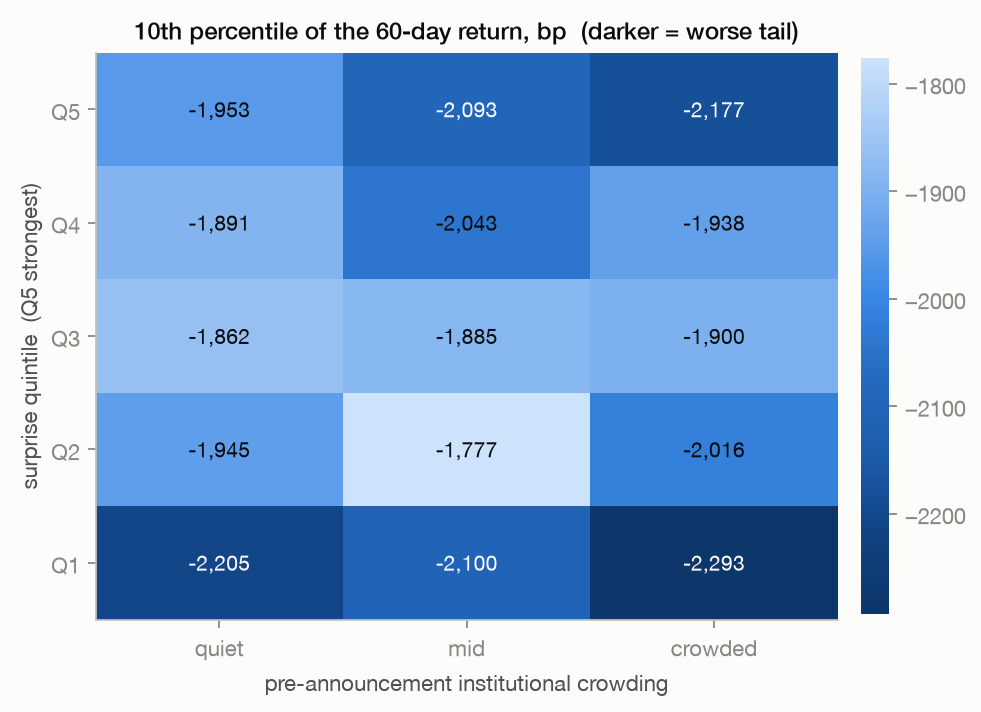

In [ ]:
# Step 4 - baseline expectation heatmap (p10)

## Step 5 - After the strongest surprises: quiet against crowded

`data: market + investor_flow + earnings filings  (provisional, strongest surprise quintile: quiet 1,263, crowded 2,735)`

**Question: where in the distribution does crowding bite?**

Declared before the run: crowded names should have a worse tenth percentile and a lower hit rate. The tenth percentile is -236 bp worse at t -3.24, outside a 200-draw placebo band of [-213, +27]. The hit rate is not different (-0.1 pp, t -0.07) and neither is the mean (-70 bp, t -0.85). The effect is concentrated in the extreme tail and fades toward the centre. The same statement holds on the four-times-larger all-filings sample (-117 bp, t -2.02, also outside its band).

| percentile of the 60-day return | crowded minus quiet (bp) | t |
| --- | --- | --- |
| p5 | -261.1 | -2.96 |
| p10 | -236.3 | -3.24 |
| p25 | -97.0 | -1.33 |
| p50 | -63.5 | -0.72 |


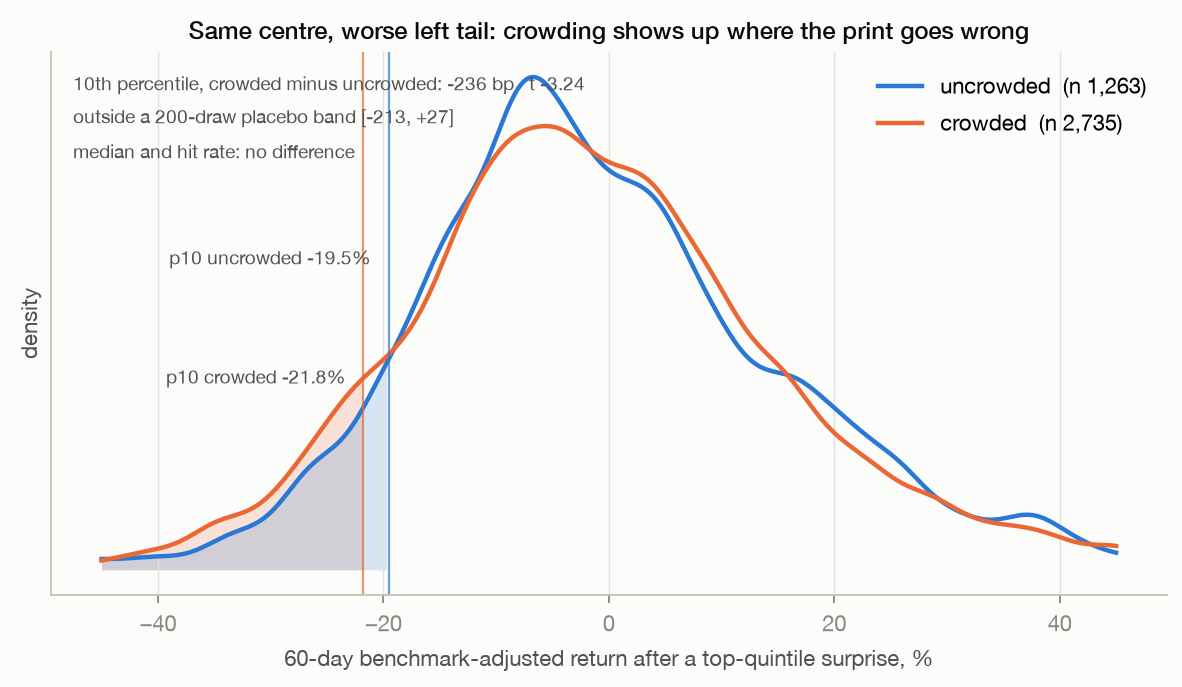

In [ ]:
# Step 5 - distribution after strong surprises

## Step 6 - Does the tail gap survive the obvious attacks?

`data: results of Step 5, split by volatility tercile and by half of the sample`

**Question: is it a volatility artefact, and does it hold over time?**

Two checks, signs declared in advance: the gap should be negative inside every volatility tercile and in both halves. It is negative in both halves in both samples, though in provisional filings it is concentrated in the second half; the larger all-filings sample is stable across both. It is not negative in every volatility tercile -- in provisional filings it is close to zero in low-volatility names and -401.9 bp in high-volatility names (t -2.92). That is a scope condition rather than a confound: the comparison inside the high-volatility tercile holds volatility fixed and the gap is still there. The finding belongs to volatile names.

| subsample | crowded minus quiet, p10 (bp) | t | seasons |
| --- | --- | --- | --- |
| provisional: low vol | +24.1 | +0.13 | 29 |
| provisional: mid vol | -99.4 | -0.70 | 51 |
| provisional: high vol | -401.9 | -2.92 | 57 |
| provisional: first half | -53.8 | -0.59 | 33 |
| provisional: second half | -463.0 | -5.10 | 28 |
| all filings: low vol | -1.5 | -0.02 | 60 |
| all filings: mid vol | -105.6 | -1.40 | 62 |
| all filings: high vol | -39.2 | -0.54 | 62 |
| all filings: first half | -125.3 | -1.50 | 39 |
| all filings: second half | -108.2 | -1.54 | 23 |


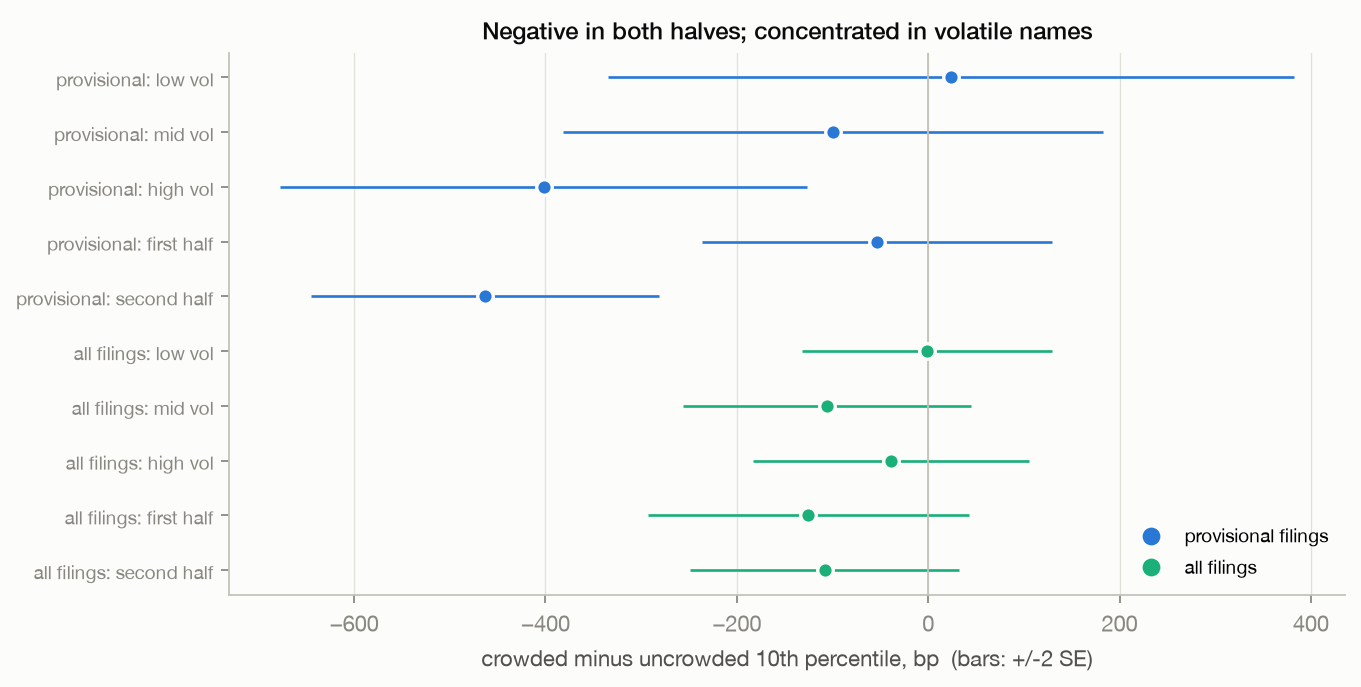

In [ ]:
# Step 6 - robustness of the tail gap

## Step 7 - A mechanism, proposed and refuted

`data: results of Step 5, split by turnover tercile and by short-selling regime`

**Question: is the worse tail an exit-friction effect?**

The natural story is that a crowded print that disappoints has everyone leaving through the same narrow door. It makes two predictions: the gap should be worst where turnover is low, and worse during the short-selling bans, when the natural counterparty to an unwind is absent. Neither holds across both samples. In provisional filings the gap is largest where turnover is *highest*, the opposite of a narrow-door story, and the two samples disagree on the sign of the ban effect. The tail pattern stands; its mechanism is open. No replacement story is offered here, because one built after seeing this table would be exactly the kind of result this record was written to avoid.

| split | provisional: p10 gap (t) | all filings: p10 gap (t) |
| --- | --- | --- |
| low turnover | +30.5 (+0.24) | -64.3 (-0.99) |
| mid turnover | -254.8 (-1.99) | -145.0 (-1.80) |
| high turnover | -437.5 (-2.65) | +12.4 (+0.15) |
| short selling banned | -503.3 (-3.59) | -85.9 (-1.02) |
| short selling allowed | -182.7 (-2.34) | -140.7 (-2.12) |


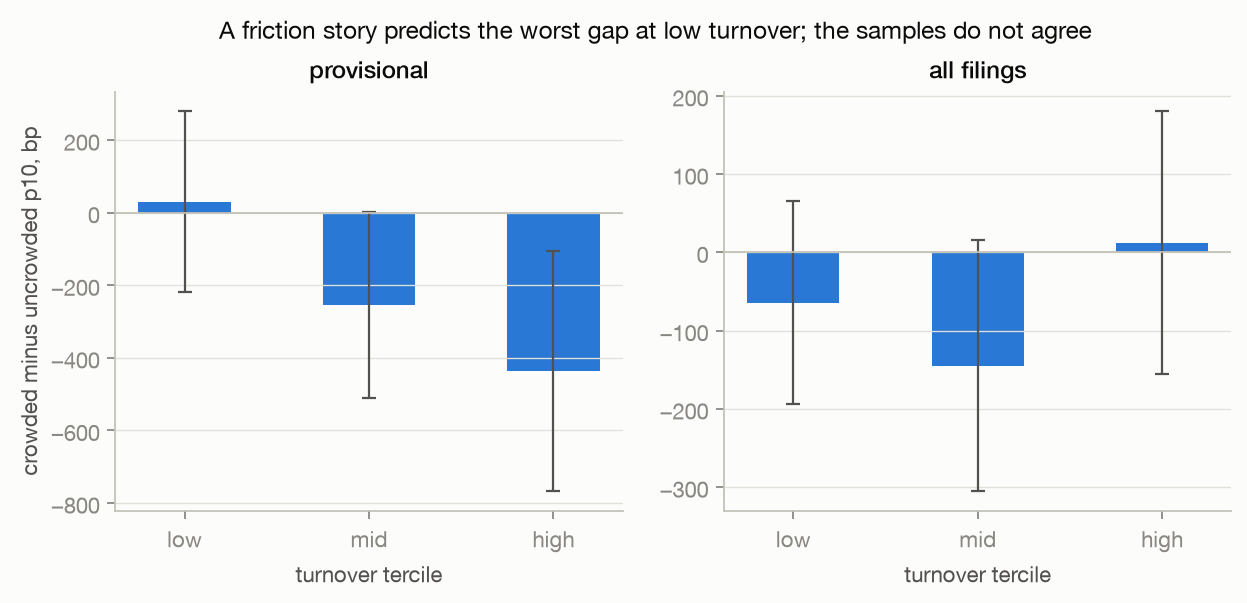

In [ ]:
# Step 7 - mechanism test

# Part C - What was corrected along the way

## Step 8 - Why an earlier headline read -117.7

`data: market + investor_flow + earnings filings  (provisional, 2011-2026)`

**Question: how much of a coefficient can one default setting create?**

An earlier version of this research reported -117.7 bp/SD on the 2018-2026 window. It came from weighting each announcement day equally after discarding days carrying fewer than 25 filings; the same setting on the full 2011-2026 window below reads -110.1. Korean earnings arrive in bursts, with day counts from one to several hundred, and the two choices compound. Sweeping the threshold moves the coefficient across the table below. Weighting each position equally and clustering on the reporting season -- the estimator used everywhere else in this record -- gives the figures in Part A. The retraction is recorded rather than removed.

| minimum filings per day | day-weighted coefficient (bp/SD) | t | days used |
| --- | --- | --- | --- |
| 5 | +7.2 | +0.12 | 1,095 |
| 10 | -57.0 | -2.11 | 749 |
| 15 | -64.6 | -2.57 | 515 |
| 25 | -110.1 | -3.75 | 215 |
| 40 | -107.0 | -2.05 | 38 |


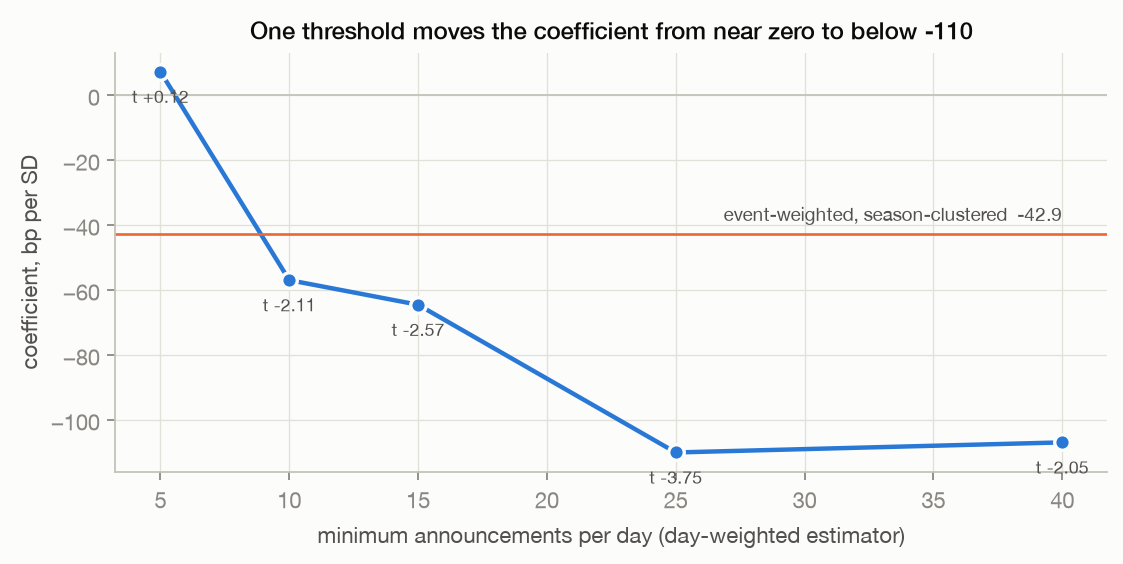

In [ ]:
# Step 8 - the min_n sweep

## Step 9 - Doubling the sample, and looking for a break

`data: market + investor_flow + earnings filings, extended from 2018 back to 2011`

**Question: does the effect hold in years never examined while the hypothesis was formed?**

The event set was extended from 2018 back to 2011, raising the reporting seasons from 34 to 61. The rule was fixed beforehand: use the maximum window the data allows and report both. The added 2011-2017 block reads -7.4 bp/SD (t -0.35) against -61.9 (t -2.71) for the original window; the change is -50.4 bp at t -1.62, not distinguishable from noise, and sweeping the break year finds no year that stands out from its neighbours. The full window is the honest estimate, and year-to-year stability cannot be claimed either way.

| break year | change in coefficient after the break (bp) | t |
| --- | --- | --- |
| 2014 | -63.2 | -1.51 |
| 2015 | -61.2 | -1.51 |
| 2016 | -36.2 | -0.98 |
| 2017 | -49.4 | -1.49 |
| 2018 | -50.4 | -1.62 |
| 2019 | -21.0 | -0.69 |
| 2020 | -38.2 | -1.31 |
| 2021 | -48.2 | -1.67 |
| 2022 | -37.3 | -1.28 |
| 2023 | -28.7 | -0.88 |


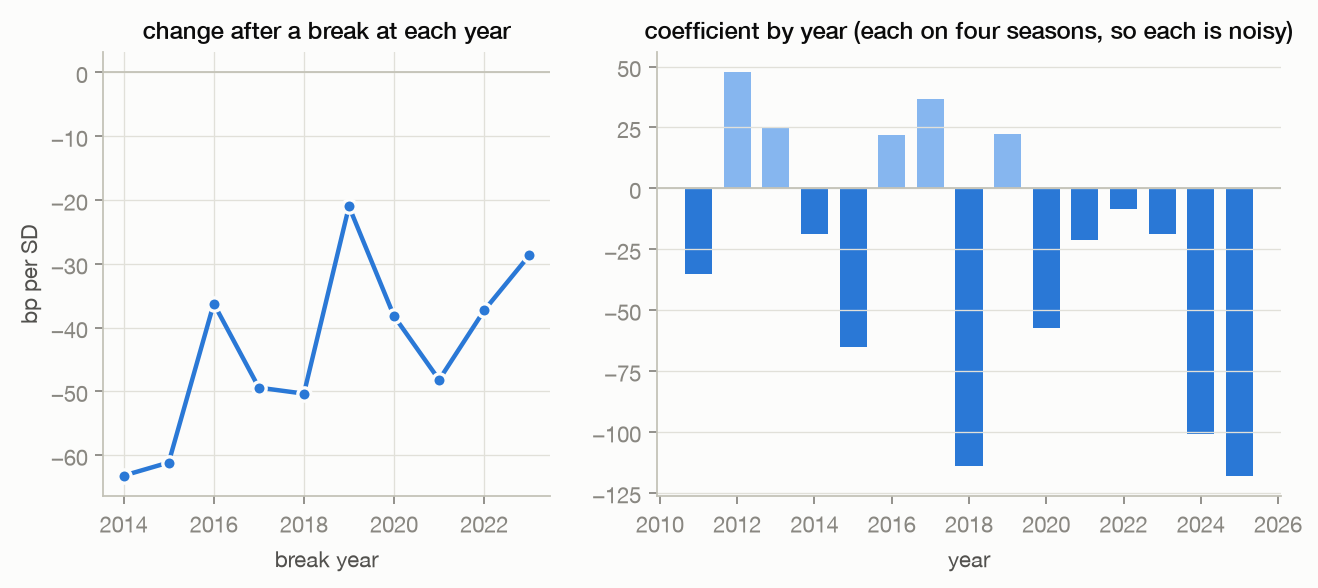

In [ ]:
# Step 9 - break-year sweep and year-by-year coefficient

## Step 10 - Tested and rejected

`data: all of the above`

**Question: what else was tried, and what did it say?**

Every hypothesis below had its sign written down before it was run. All of them failed. They are listed because a record of what did not work is what makes the two or three things that did work believable.

| claim | result |
| --- | --- |
| foreign flow predicts post-announcement returns | +9.8 bp/SD, t +0.59 |
| surprise x flow interaction (positioning conditions the drift) | -6.6 bp, t -0.43 |
| surprise x prior run-up interaction | -17.5 bp, t -1.13 |
| the effect survives in flow orthogonalised to momentum | top-minus-bottom after, -31.0 bp, t -0.79 |
| ownership level carries what flow does not | f_level +8.9 bp/SD, t +0.48; ladder ordering rho +0.23 |
| index rebalancing explains the effect | size interaction +28.2 bp, t +0.58 -- wrong sign |
| the effect is amplified in market-wide buying waves | interaction -53.5 bp, t -0.83 on the full sample |
| pension funds are a separable carrier of the aggregate | alone -64.7 bp/SD (t -2.95); entered with the aggregate, neither survives |
| the long side (buying uncrowded surprises) earns a premium | inside a 200-draw placebo band in both samples |
| exit friction explains the tail gap | predictions fail across samples (Step 7) |


# Part D - Design decisions and bottom line

## Every design decision, side by side

| decision | alternatives tested | chosen | why |
| --- | --- | --- | --- |
| weighting | one vote per day (min_n 5-40) / one vote per position | one vote per position | day-weighting is a function of an arbitrary threshold (Step 8) |
| inference | day clusters / Newey-West on days / season clusters | reporting season | Korean filings arrive in four bursts a year; the season is the independent unit |
| sample window | 2018-2026 / 2011-2026 | 2011-2026, both reported | maximum available, fixed before the extension; no break year stands out (Step 9) |
| positioning measure | 20d flow / 60d flow / 20d ownership change / ownership level | 20d institutional flow | none of the alternatives carries more; all are records of price (Steps 1, 10) |
| outcome statistic | mean / hit rate / percentiles | tenth percentile | the mean does not move with crowding; the tail does (Steps 4-5) |
| scope | all names / by volatility | volatile names | the gap is near zero in low-volatility names (Step 6) |
| multiplicity | none / Bonferroni / permutation | permutation family bars and 200-draw placebo bands | the search is explicit and the bar is empirical |
| mechanism | exit friction | none claimed | both predictions fail across samples (Step 7) |


## Bottom line

- **The daily flow disclosure is a record, not a forecast.** Flow quintiles separate by +985 bp before an announcement (t +29.5) and by +37 bp after it (t +0.75). This is why the foreign-ownership series carries nothing (+9.8 bp/SD, t +0.59), and why every forward-looking test built on flow failed. Positioning flow belongs in a model as a state variable, not as a predictive feature.
- **Positioning does inform the baseline -- in the tail.** After the strongest surprises, names institutions were already crowded into have a tenth percentile -236 bp worse (t -3.24, outside a 200-draw placebo band), with no difference in median or hit rate. The effect is concentrated in volatile names and holds in both halves of the larger sample. Its mechanism is open: an exit-friction account was tested and refuted.
- **As a filter on an existing surprise book**, excluding crowded names adds about +28 bp per position (+1.1% a year) at no extra turnover, t +1.14 -- directional, not established. The value of the finding is in sizing the downside, not in the mean.
- **Earnings drift itself is present and monotone** across surprise quintiles (-122 bp to +124 bp over 60 days, weakest to strongest surprise); positioning does not add to its mean.
- **Limits stated plainly:** the sample is a single market with no holdout; the tail finding rests on one pre-declared test plus its robustness checks; the coefficient on the mean depends on the momentum controls; short-interest data, the natural level-type complement, is unusable in Korea for half the sample because of the 2020-21 and 2023-25 bans.
- **Next, in order:** the same tail statistic on a market whose disclosure is a level rather than a flow -- participant holdings and short balances -- where the record above says the information, if any, should live.
